**Title : Personal Loan Approval Prediction System**

**Group No. : 05**

**Members: Anujan I. -EG/2020/3823, Mathushagan J. - EG/2020/4072**

**Introduction**

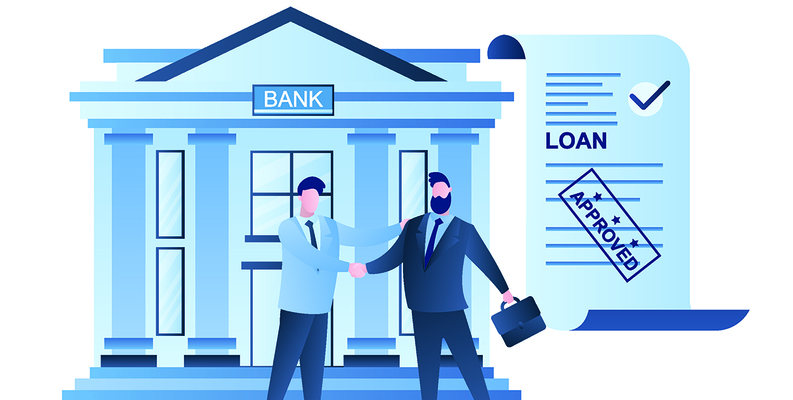

Personal loans are a key financial product for banks, offering both profitability and customer engagement opportunities. However, not every customer is likely to accept such offers, and indiscriminate targeting can result in wasted marketing resources. Identifying the right customers for personal loan offers is therefore essential for improving campaign effectiveness and customer satisfaction.

Machine learning provides powerful tools to predict customer behavior by analyzing demographic, financial, and behavioral data. Predictive models can help banks identify customers who are most likely to accept a personal loan, enabling targeted marketing and efficient resource allocation.

This project aims to develop a machine learning-based system to predict personal loan acceptance using the Bank Personal Loan Dataset. The study explores two classification models: K-Nearest Neighbors (KNN) and Naive Bayes, evaluating their effectiveness in identifying potential loan acceptors. The ultimate goal is to provide actionable insights that can assist banks in improving marketing strategies and customer retention.

**Literature Survey**

Loan acceptance prediction has been widely studied in financial data analytics, with various machine learning models applied to identify potential customers:

Logistic Regression has often been used as a baseline due to its simplicity and interpretability, but its performance is limited in capturing complex relationships [1].

K-Nearest Neighbors (KNN) is a non-parametric model that classifies customers based on similarity to their neighbors. Several studies have shown KNN to be effective in financial datasets, particularly when relationships between features are non-linear. However, its performance can be sensitive to the choice of distance metric and the value of k [2].

Naive Bayes leverages probabilistic modeling based on Bayes’ theorem, assuming independence between features. Despite this strong assumption, Naive Bayes has been shown to perform well in classification tasks, especially with high-dimensional or categorical data [3].

Comparative research often highlights that while ensemble models like Random Forest or Gradient Boosting achieve higher predictive accuracy, simpler models such as KNN and Naive Bayes remain valuable due to their computational efficiency and ease of implementation [4].

In banking contexts, income, credit card spending, and education have consistently been identified as strong predictors of loan acceptance. Models that balance interpretability and predictive accuracy are preferred for practical applications in financial services.

In summary, KNN and Naive Bayes offer two contrasting yet complementary approaches: one based on distance similarity and the other on probabilistic inference. Their evaluation in this study helps determine their suitability for personal loan prediction.

**Dataset Description**

The dataset contains 5,000 customer records, each described by demographic, financial, and behavioral features. The target variable is Personal Loan, indicating whether the customer accepted the loan offer (1 = Yes, 0 = No).

Key Features:

* ID – Unique identifier for each customer

* Age – Age of the customer (years)

* Experience – Work experience in years

* Income – Annual income of the customer

* ZIP Code – Customer’s location (ZIP code)

* Family – Number of dependents in the family

* CCAvg – Average monthly credit card spending

* Education – Education level (1 = Undergrad, 2 = Graduate, 3 = Advanced/Professional)

* Mortgage – Mortgage amount owed

* Securities Account – Binary (1 = Yes, 0 = No)

* CD Account – Binary (1 = Yes, 0 = No)

* Online – Binary (1 = Yes, 0 = No, uses online banking)

* CreditCard – Binary (1 = Yes, 0 = No, has bank credit card)

* Personal Loan (Target) – Binary (1 = Accepted, 0 = Not Accepted)


The dataset allows exploration of both financial standing (Income, CCAvg, Mortgage) and customer behavior (Online usage, Credit Card, CD Account), making it suitable for building predictive models.

**Algorithms Used**

K-Nearest Neighbors (KNN):

Classifies a customer based on the majority class of its nearest neighbors in feature space.

Suitable for non-linear data distributions.

Hyperparameters include the number of neighbors (k) and the distance metric (e.g., Euclidean, Manhattan).

Naive Bayes:

A probabilistic classifier based on Bayes’ theorem, assuming independence between features.

Works well with categorical and continuous variables.

Efficient in training and prediction, making it practical for large datasets.

**Importing Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Loading Data**

In [2]:
df = pd.read_csv('/content/drive/MyDrive/ML workshop/Bank_Personal_Loan.csv')
df.head()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1/60,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1/50,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1/00,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2/70,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1/00,2,0,0,0,0,0,1


In [3]:
df.describe()

,ID,Age,Experience,Income,ZIP Code,Family,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93152.503000,2.396400,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,2121.852197,1.147663,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,9307.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


In [ ]:
df.shape

(5000, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   ID                  5000 non-null   int64 
 1   Age                 5000 non-null   int64 
 2   Experience          5000 non-null   int64 
 3   Income              5000 non-null   int64 
 4   ZIP Code            5000 non-null   int64 
 5   Family              5000 non-null   int64 
 6   CCAvg               5000 non-null   object
 7   Education           5000 non-null   int64 
 8   Mortgage            5000 non-null   int64 
 9   Personal Loan       5000 non-null   int64 
 10  Securities Account  5000 non-null   int64 
 11  CD Account          5000 non-null   int64 
 12  Online              5000 non-null   int64 
 13  CreditCard          5000 non-null   int64 
dtypes: int64(13), object(1)
memory usage: 547.0+ KB


**Data Preprocessing**

In [4]:
# here no string  data types so , no need to change string to int
#selecting rows where the 'Experience' is less than 0.
df2 = df[df['Experience']<0]

# display where experiece <0
df2.head()
# in this data set experience are in negative values also there

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
89,90,25,-1,113,94303,4,2/30,3,0,0,0,0,0,1
226,227,24,-1,39,94085,2,1/70,2,0,0,0,0,0,0
315,316,24,-2,51,90630,3,0/30,3,0,0,0,0,1,0
451,452,28,-2,48,94132,2,1/75,3,89,0,0,0,1,0
524,525,24,-1,75,93014,4,0/20,1,0,0,0,0,1,0


In [ ]:
# Impute negative values with the median of non-negative values
median_experience = df['Experience'][df['Experience'] >= 0].median()
df['Experience'] = df['Experience'].apply(lambda x: x if x >= 0 else median_experience)

In [ ]:
#check any negative values are there
df3 = df[df['Experience']<0]
df3.shape


(0, 14)

In [5]:
# here ccAvg in object datatype but we consider to predict Personal Loan using only age, income, Education, Mortgage, Credit card, CD Account
#now get no zero values raw

# now drop unwanted coloums for EDA

df = df.drop(['ID','ZIP Code','Family','CCAvg','Securities Account','CreditCard','Online'], axis =1)
df.head()

,Age,Experience,Income,Education,Mortgage,Personal Loan,CD Account
0,25,1,49,1,0,0,0
1,45,19,34,1,0,0,0
2,39,15,11,1,0,0,0
3,35,9,100,2,0,0,0
4,35,8,45,2,0,0,0


In [6]:
# remove rows with missing values

df = df.dropna(axis = 0)
df.shape

(5000, 7)

In [7]:
df.columns

Index(['Age', 'Experience', 'Income', 'Education', 'Mortgage', 'Personal Loan',
       'CD Account'],
      dtype='object')

Box wisker plots for out liers

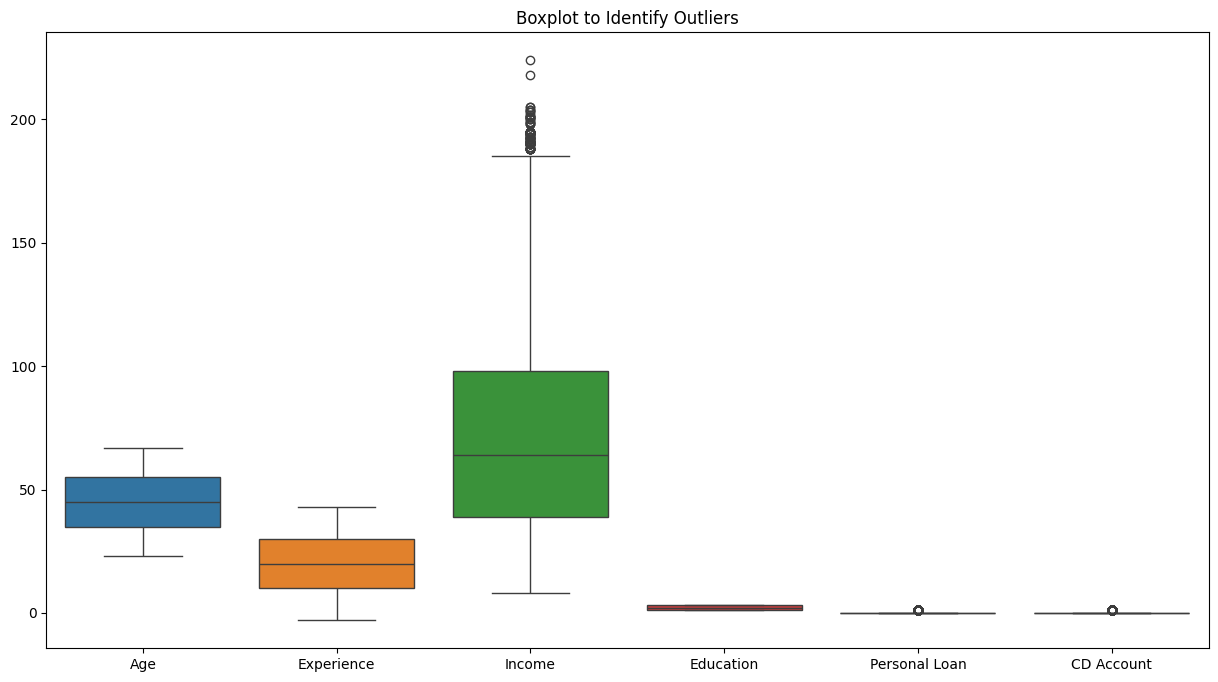

In [8]:
plt.figure(figsize=(15, 8))
sns.boxplot(data=df[['Age', 'Experience', 'Income', 'Education','Personal Loan','CD Account']])
plt.title('Boxplot to Identify Outliers')
plt.show()

In [9]:
# remove out liers
# Handling outliers using IQR (Interquartile Range)
def remove_outliers(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = np.where((df[column] < lower_bound) | (df[column] > upper_bound), np.nan, df[column])

    # Remove outliers for specified columns
columns_with_outliers = ['Income']
for column in columns_with_outliers:
    remove_outliers(column)

    # Drop rows with missing values after outlier removal
df = df.dropna(axis=0)

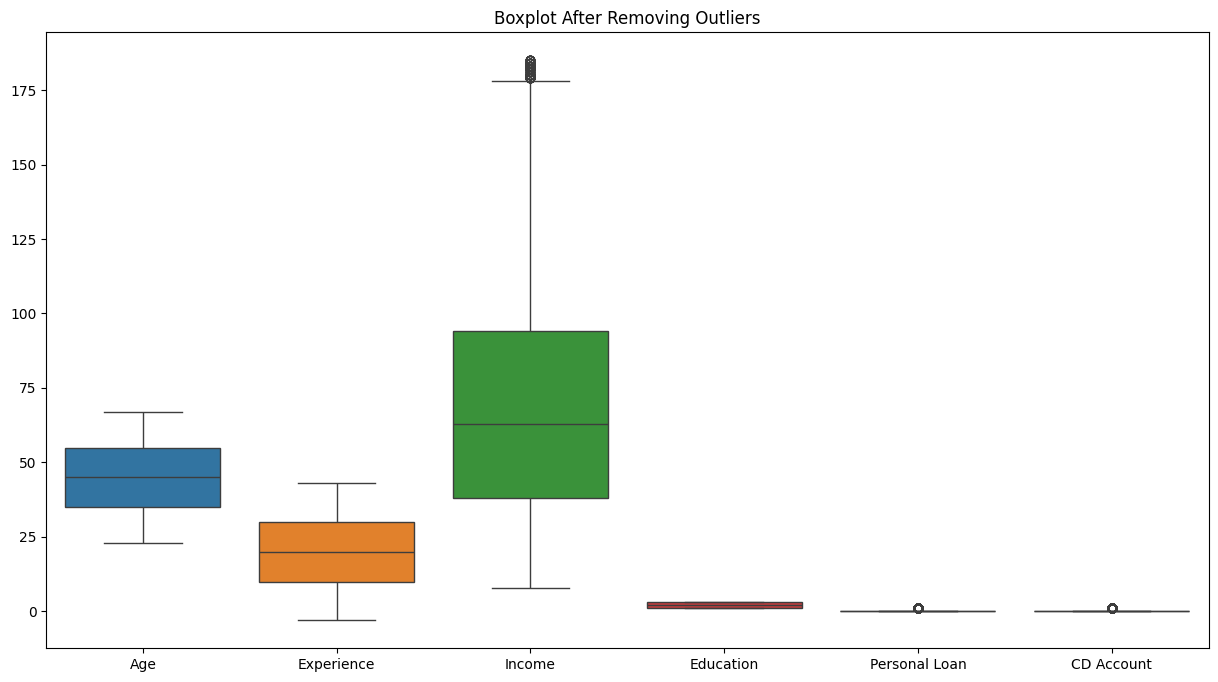

In [10]:
plt.figure(figsize=(15, 8))
sns.boxplot(data=df[['Age', 'Experience', 'Income', 'Education','Personal Loan','CD Account']])
plt.title('Boxplot After Removing Outliers')
plt.show()

**Data Visualization**

1)Univariate analysis

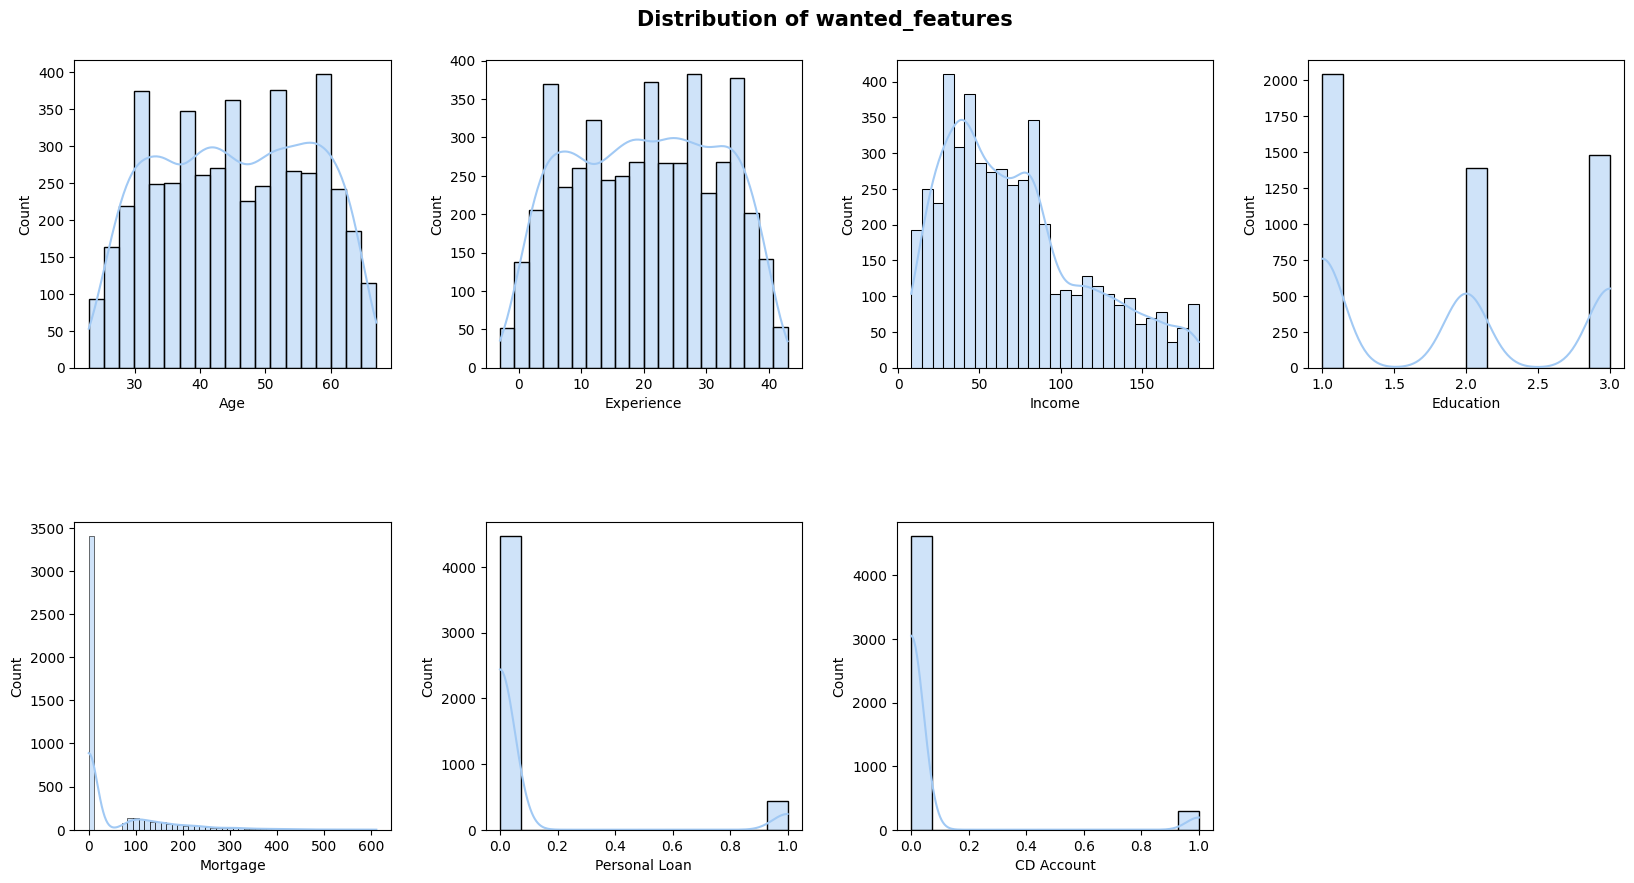

In [11]:
# Assuming continuous_features is a list of your continuous feature column names
# Also, assuming df is your DataFrame containing these continuous features

# Set the pink color palette
sns.set_palette("pastel")

# Create subplots
fig, ax = plt.subplots(2, 4, figsize=(20, 10), gridspec_kw={"hspace": 0.5, "wspace": 0.3})

# Iterate through continuous features and create histograms
for i, col in enumerate(df):
    sns.histplot(df[col], kde=True, ax=ax[i // 4, i % 4])

# Set the overall title for the entire subplot grid
fig.suptitle('Distribution of wanted_features', fontsize=15, fontweight='bold', y=0.93)

# Remove empty subplots for the case where there are fewer features than subplots
for i in range(len(df), 2*4):
    fig.delaxes(ax.flatten()[i])


# Remove the last empty subplot
fig.delaxes(ax[1, 3])

# Display the plots
plt.show()


2) Kernel Density Estimation (KDE) of wanted_features by Personal Loan

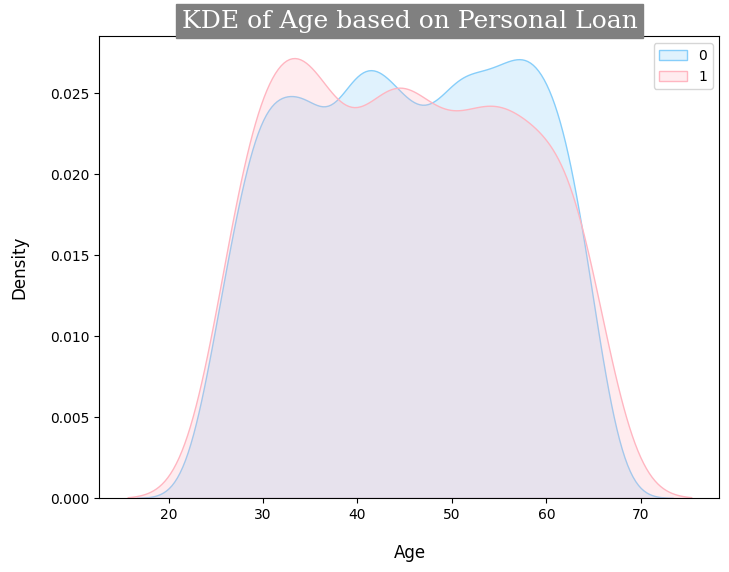

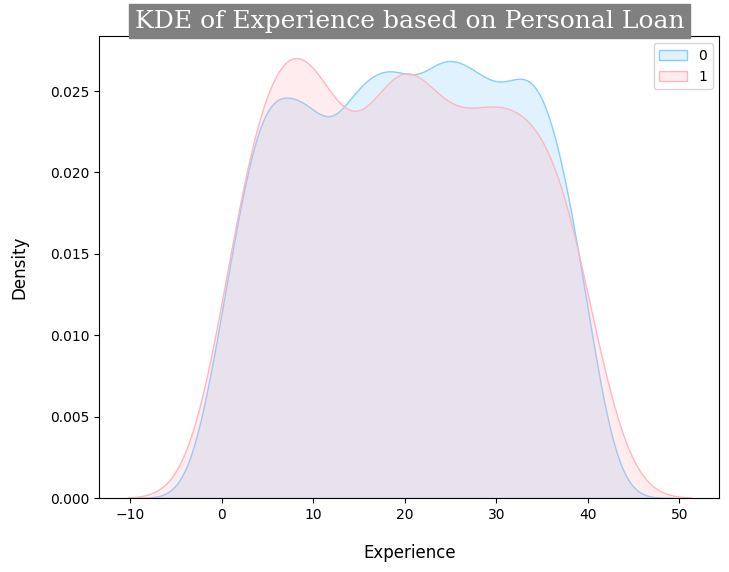

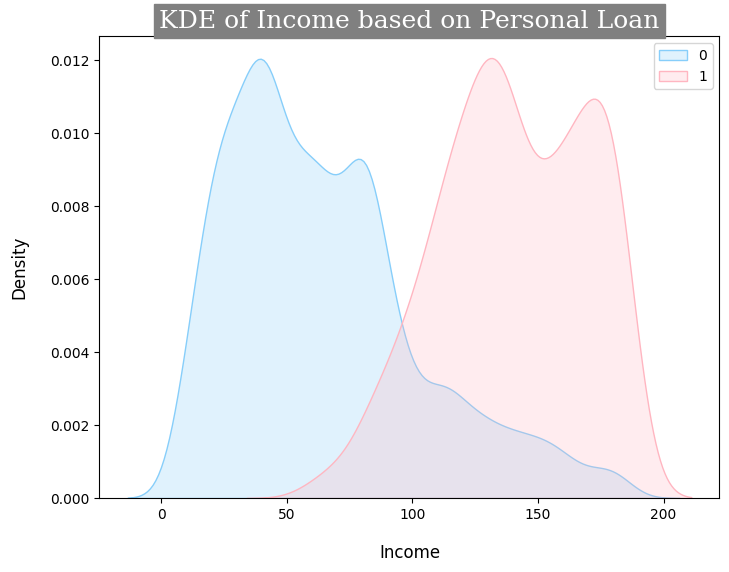

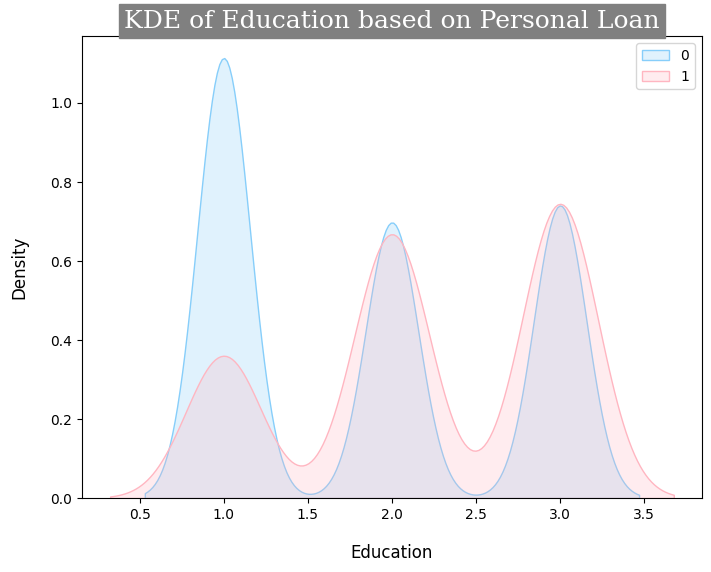

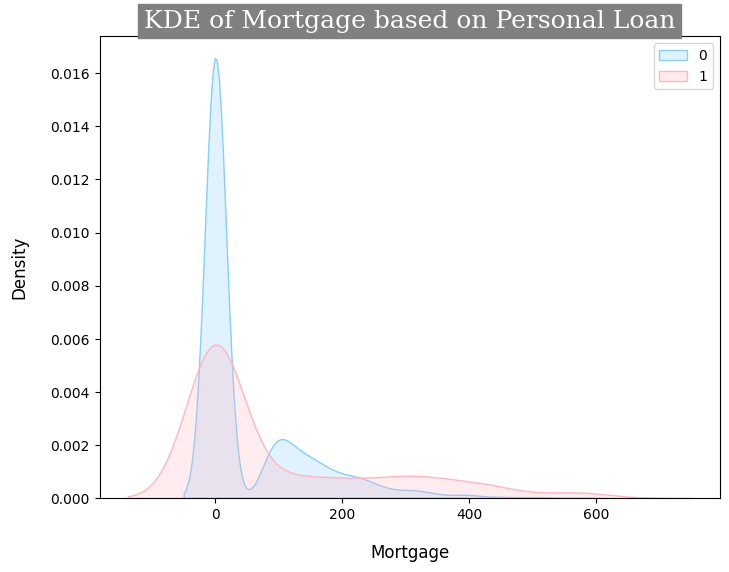

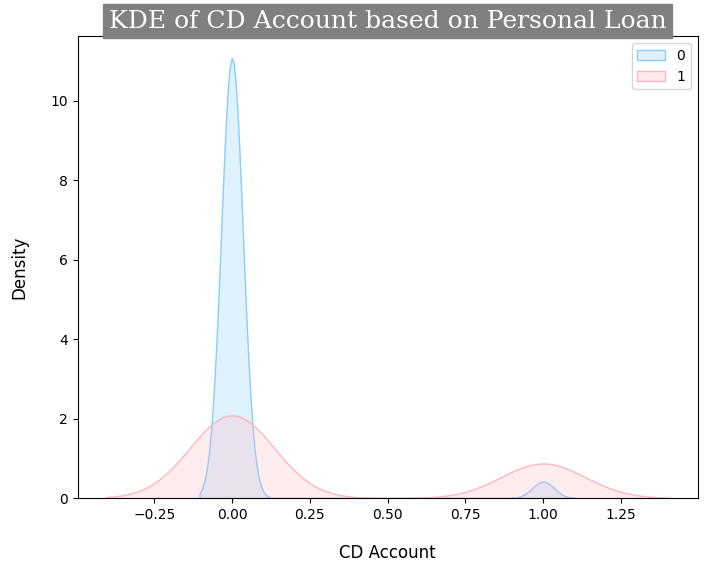

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming wanted_features is a DataFrame with wanted_features and 'Personal Loan'
# Adjust the column names as needed

font1 = {'family': 'serif', 'size': 18}
font2 = {'family': 'serif', 'size': 15}

# Set the color palette
sns.set_palette(['lightskyblue', 'lightpink', 'cadetblue', 'yellowgreen'])

for j, col in enumerate(df.drop(columns=['Personal Loan'])):
    plt.figure(figsize=(8, 6))

    for i, label in enumerate(df["Personal Loan"].unique().tolist()):
        sns.kdeplot(df.loc[df['Personal Loan'] == label, col], label=label, fill=True)

    plt.title(f"KDE of {col} based on Personal Loan", backgroundcolor='grey', color='white', fontdict=font1)
    plt.xlabel(f"{col}", fontsize=12, labelpad=16)
    plt.ylabel("Density", fontsize=12, labelpad=16)

    plt.legend()
    plt.show()

**Correlation Matrix Heatmap**

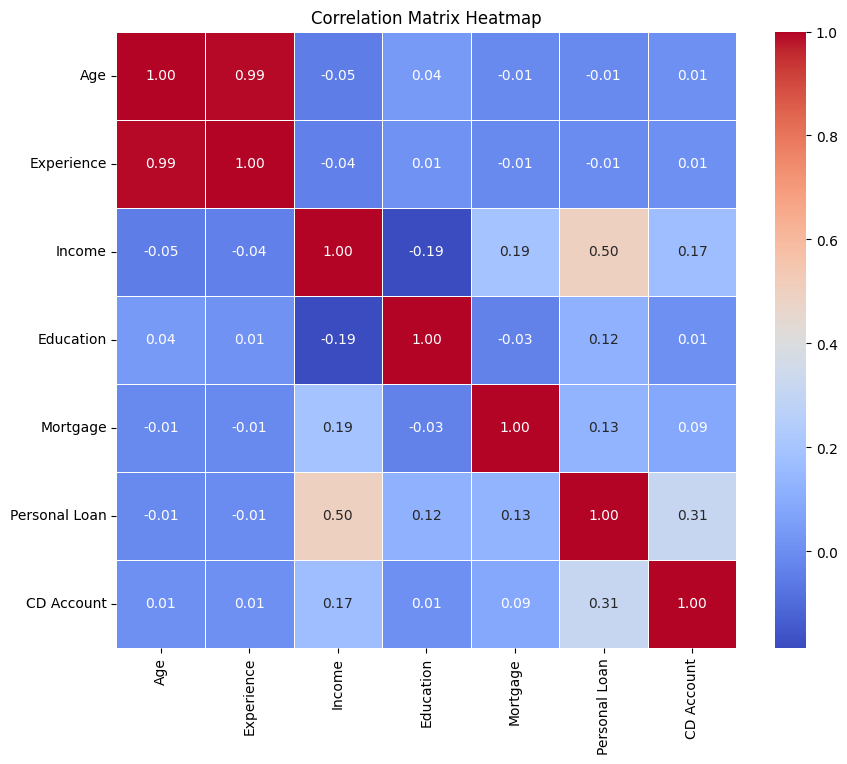

In [14]:
selected_columns = ['Age', 'Experience', 'Income', 'Education', 'Mortgage', 'Personal Loan', 'CD Account']
subset_df = df[selected_columns]
correlation_matrix = subset_df.corr()

# Plot heatmap using seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()


**Feature Selection**

During the preprocessing stage, the correlation between input variables was analyzed. It was observed that Age and Experience had a very high positive correlation, indicating redundancy between these two features. Since including both could lead to multicollinearity and does not contribute significant additional information to the model, one of the features was removed. Specifically, the Experience attribute was dropped, while Age was retained, as it provided a more intuitive and interpretable measure for loan prediction.

**Feature scalling**

In [16]:
from sklearn.preprocessing import StandardScaler

X = df[['Age', 'Income', 'Education', 'Mortgage', 'CD Account']]
y = df['Personal Loan']

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**Defining Features and Target**

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

**KNN**

In [19]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Initialize KNN model (default k=5)
knn = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn.fit(X_train, y_train)

# Make predictions
predictions = knn.predict(X_test)

# Evaluate the model
print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))
print('Accuracy is : ', accuracy_score(y_test, predictions))
print()


[[895   5]
 [ 26  55]]
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       900
           1       0.92      0.68      0.78        81

    accuracy                           0.97       981
   macro avg       0.94      0.84      0.88       981
weighted avg       0.97      0.97      0.97       981

Accuracy is :  0.9683995922528033



**Naive Bayes**

In [20]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Initialize Naive Bayes model
nb = GaussianNB()

# Train the model
nb.fit(X_train, y_train)

# Make predictions
predictions = nb.predict(X_test)

# Evaluate the model
print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))
print('Accuracy is : ', accuracy_score(y_test, predictions))
print()


[[853  47]
 [ 41  40]]
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       900
           1       0.46      0.49      0.48        81

    accuracy                           0.91       981
   macro avg       0.71      0.72      0.71       981
weighted avg       0.91      0.91      0.91       981

Accuracy is :  0.910295616717635



Confusion matrix

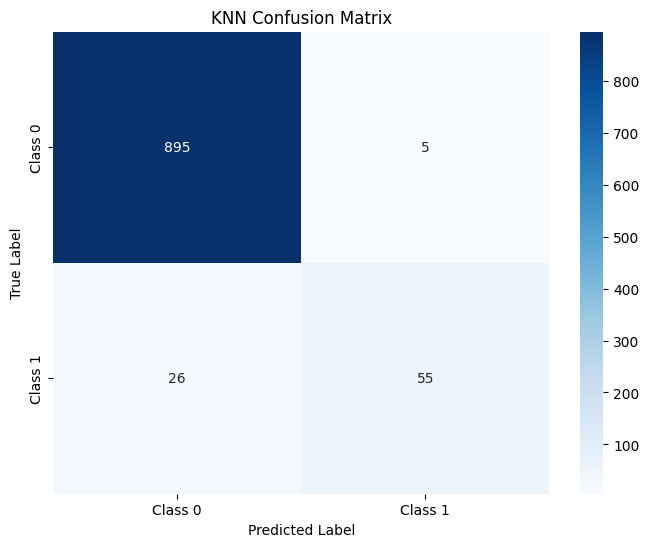

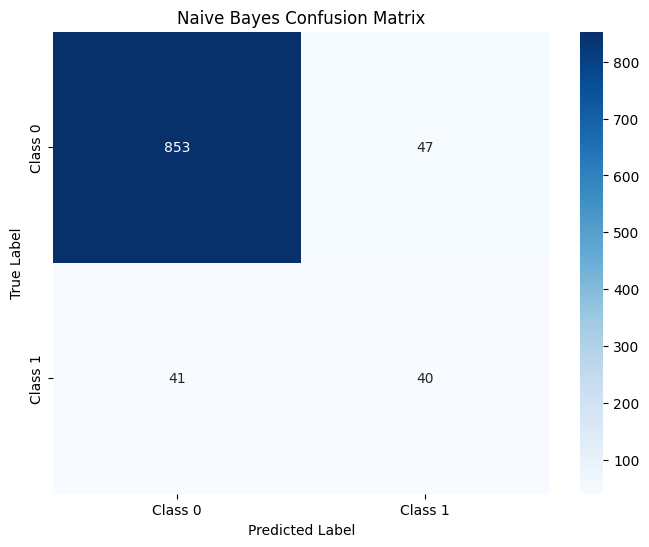

In [24]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ---- Train Models ----
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_predictions = knn.predict(X_test)

nb = GaussianNB()
nb.fit(X_train, y_train)
nb_predictions = nb.predict(X_test)

# ---- Confusion Matrices ----
knn_conf_matrix = confusion_matrix(y_test, knn_predictions)
nb_conf_matrix = confusion_matrix(y_test, nb_predictions)

# ---- Plot KNN ----
plt.figure(figsize=(8, 6))
sns.heatmap(knn_conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# ---- Plot Naive Bayes ----
plt.figure(figsize=(8, 6))
sns.heatmap(nb_conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()



**Conclusion**

In this project, different machine learning algorithms were applied to predict Personal Loan acceptance based on customer demographic and financial features. The evaluation of models was carried out using performance metrics such as accuracy, precision, recall, and F1-score.

The K-Nearest Neighbors (KNN) classifier achieved the highest performance with an accuracy of 96.8%, demonstrating excellent predictive capability for customers who did not accept a loan (class 0) and relatively good results for those who accepted (class 1). However, its recall for class 1 (loan acceptance) was lower compared to class 0, suggesting some limitations in capturing minority class patterns.

On the other hand, the Naive Bayes classifier achieved an accuracy of 91%, but its performance in predicting loan acceptance (class 1) was significantly weaker, with lower precision and recall. This indicates that Naive Bayes struggles with the data distribution and underlying feature dependencies.

Overall, the results indicate that KNN outperformed Naive Bayes for this dataset and can be considered a more reliable model for predicting personal loan acceptance. However, the relatively lower recall for loan acceptance cases highlights the need for further model improvement or the exploration of advanced classification techniques (e.g., Random Forest, Gradient Boosting, or Logistic Regression) to enhance detection of potential loan applicants.

**References**

[1] S. Moro, P. Cortez, and P. Rita, “A data-driven approach to predict the success of bank telemarketing,” Decision Support Systems, vol. 62, pp. 22–31, Jun. 2014.

[2] S. S. Sonawane and D. S. Gaikwad, “Prediction of loan approval using K-Nearest Neighbor and Decision Tree,” in Proc. Int. Conf. Communication and Signal Processing (ICCSP), Chennai, India, Apr. 2019, pp. 1111–1115.

[3] M. A. Ghatasheh, “Business analytics using naive Bayes classification,” in Proc. Int. Conf. Future Internet of Things and Cloud, Barcelona, Spain, Aug. 2014, pp. 307–312.

[4] A. K. Goyal and R. S. Khanduja, “Loan default prediction using machine learning techniques,” International Journal of Innovative Technology and Exploring Engineering (IJITEE), vol. 9, no. 1, pp. 951–956, Nov. 2019.

[5] G. M. Foong, M. E. E. Ibrahim, and M. A. H. Ali, “Machine learning approaches for predicting personal loan acceptance,” in Proc. IEEE 9th Int. Conf. System Engineering and Technology (ICSET), Shah Alam, Malaysia, Oct. 2019, pp. 28–33.

[6] N. Patil and P. S. Pawar, “Loan approval prediction based on machine learning approach,” in Proc. Int. Conf. Computing, Communication, Control and Automation (ICCUBEA), Pune, India, Aug. 2017, pp. 1–6.